# Notebook 08 — GAM: Weather Effects on Cycling Demand

## 0. Imports & Setup

In [37]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pygam"])


0

In [38]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import LinearGAM, PoissonGAM, s, f, l # Generalized Additive Models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [39]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print("\nRows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print("\nsite_type distribution:")
print(panel_good['site_type'].value_counts().to_string())


Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
commuter    72143
leisure     44342
mixed       27853


## 0b. Train-only IQR Outlier Audit

Calculate per-site upper fences (`Q3 + 3 × IQR`) using **train data only** (2023–2024).  
Stations where `IQR = 0` (sparse/mostly-zero counters) are excluded from flagging.

Output: all train observations with ratio ≥ 5× the per-site median, sorted by severity.  
Use this list to decide which dates belong in `remove_dates` (data errors) vs `event_dates` (known events) in section 0c below.

In [40]:
# ── per-site IQR stats on train only ──────────────────────────────────
def site_stats(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    return pd.Series({"q1": q1, "q3": q3, "iqr": iqr,
                      "median": x.median(), "upper_fence": q3 + 3 * iqr})

_train_for_iqr = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
_stats = _train_for_iqr.groupby("site ID")["aantal"].apply(site_stats).unstack()
_train_for_iqr = _train_for_iqr.merge(_stats, on="site ID")

# Flag rows exceeding the fence (skip IQR=0 stations — degenerate/sparse counters)
_outliers = _train_for_iqr[
    (_train_for_iqr["aantal"] > _train_for_iqr["upper_fence"]) &
    (_train_for_iqr["iqr"] > 0)
].copy()
_outliers["ratio"] = (_outliers["aantal"] / _outliers["median"]).round(1)

print(f"Total flagged (Q3 + 3×IQR, train 2023–2024): {len(_outliers)}")

# ── candidates grouped by site, sites ordered by max ratio ────────────
_candidates = _outliers[_outliers["ratio"] >= 5][
    ["site ID", "naam", "date", "aantal", "median", "upper_fence", "ratio"]
].copy()

_site_max = _candidates.groupby("site ID")["ratio"].max().rename("site_max")
_candidates = (_candidates
    .merge(_site_max, on="site ID")
    .sort_values(["site_max", "site ID", "ratio"], ascending=[False, True, False])
    .drop(columns="site_max")
)

print()
print("=" * 80)
print("CANDIDATES WITH RATIO ≥ 5× MEDIAN  (grouped by site, ↓ ratio)")
print("=" * 80)
_current_site = None
for _, row in _candidates.iterrows():
    if row["site ID"] != _current_site:
        _current_site = row["site ID"]
        site_n = _candidates[_candidates["site ID"] == _current_site].shape[0]
        print(f"\n  site {int(row['site ID']):<4}  {row['naam']}  [{site_n} flagged date(s)]")
    print(f"    {str(row['date'])[:10]}  aantal={int(row['aantal']):>6}  "
          f"median={row['median']:>6.1f}  fence={row['upper_fence']:>8.1f}  ratio={row['ratio']:.1f}x")

# ── degenerate stations (IQR = 0) ─────────────────────────────────────
print()
print("=" * 80)
print("STATIONS WITH IQR=0 (excluded — sparse/mostly-zero counters)")
print("=" * 80)
_zero_iqr_sites = _stats[_stats["iqr"] == 0].index.tolist()
for sid in _zero_iqr_sites:
    _rows = _train_for_iqr[_train_for_iqr["site ID"] == sid]
    naam = _rows["naam"].iloc[0] if len(_rows) else "?"
    n_nonzero = (_rows["aantal"] > 0).sum()
    print(f"  site {sid:<4} {naam[:32]:<32}  nonzero={n_nonzero}/{len(_rows)}")

Total flagged (Q3 + 3×IQR, train 2023–2024): 125

CANDIDATES WITH RATIO ≥ 5× MEDIAN  (grouped by site, ↓ ratio)

  site 105   St. pieters leeuw teller 2  [1 flagged date(s)]
    2023-03-03  aantal=   807  median=   0.0  fence=   232.0  ratio=infx

  site 85    Asse teller 1  [3 flagged date(s)]
    2024-07-25  aantal=  4823  median=  82.0  fence=   268.0  ratio=58.8x
    2024-07-21  aantal=   904  median=  82.0  fence=   268.0  ratio=11.0x
    2024-07-07  aantal=   660  median=  82.0  fence=   268.0  ratio=8.0x

  site 83    Beersel teller 2  [16 flagged date(s)]
    2024-03-31  aantal=  1796  median=  46.0  fence=   141.0  ratio=39.0x
    2024-03-19  aantal=  1748  median=  46.0  fence=   141.0  ratio=38.0x
    2024-03-30  aantal=  1720  median=  46.0  fence=   141.0  ratio=37.4x
    2024-04-06  aantal=  1534  median=  46.0  fence=   141.0  ratio=33.3x
    2024-03-29  aantal=  1443  median=  46.0  fence=   141.0  ratio=31.4x
    2024-04-01  aantal=  1217  median=  46.0  fence=   141.0

## 0c. Outlier Blacklist, Event Flags & Train/Test Split

Based on the IQR audit above, classify each candidate:
- **`remove_dates`** — likely data/sensor errors: set `aantal` to NaN
- **`event_dates`** — confirmed real events: keep value, flag with `is_event_day = 1`

Then apply removals, split into train (2023–2024) / test (2025), and compute the per-station log-mean offset from **train only**.

In [41]:
# ── outlier blacklist (informed by IQR audit above) ───────────────────
remove_dates = [
    (105, '2023-03-03'),  # St. Pieters Leeuw (median=0 station, isolated single-day spike)
    (85,  '2024-07-25'),  # Asse teller 1, 58.8x
    (20,  '2024-06-02'),  # Brugge, 20.1x
    (140, '2024-07-13'),  # Hasselt ring, 20.0x
    (129, '2024-08-12'),  # Lokeren teller 2, 19.1x
    (78,  '2023-07-01'),  # Pepingen, 15.0x
    (50,  '2024-09-18'),  # Brugge Sint-Andries, 11.9x
    (94,  '2023-08-20'),  # Herentals teller 2, 13.2x — no event found (criterium was Jul 27-28)
    (33,  '2023-01-20'),  # Lummen, 7.7x — isolated winter spike, no plausible event
    (81,  '2024-08-18'),  # Wemmel teller 2, 7.5x — isolated single day, no known event
    # Beersel teller 2 — 16-day anomaly, likely temporary detour/rerouting (site 83)
    (83,  '2024-03-19'),
    (83,  '2024-03-27'), (83,  '2024-03-28'), (83,  '2024-03-29'),
    (83,  '2024-03-30'), (83,  '2024-03-31'), (83,  '2024-04-01'),
    (83,  '2024-04-02'), (83,  '2024-04-03'), (83,  '2024-04-04'),
    (83,  '2024-04-05'), (83,  '2024-04-06'), (83,  '2024-04-07'),
    (83,  '2024-04-08'), (83,  '2024-04-09'), (83,  '2024-04-10'),
]

# ── known recurring event days (retain value, add flag) ───────────────
event_dates = [
    # Kampenhout — Super 8 Classic annual race (site 70)
    (70,  '2023-09-16'),
    (70,  '2024-09-21'),
    # Asse teller 1 — recurring July events (site 85)
    (85,  '2024-07-07'),
    (85,  '2024-07-21'),
    # Brugge Sint-Andries — May event (sites 72, 51)
    (72,  '2024-05-08'),
    (51,  '2024-05-08'),
    # Maaseik — Ronde van Maaseik (sites 43, 44)
    (43,  '2023-05-28'),
    (44,  '2023-05-28'),
    # Heers — spring cycling season / classics area (sites 28, 34)
    (28,  '2024-04-06'),
    (28,  '2024-04-13'),
    (28,  '2024-04-14'),
    (28,  '2023-04-30'),
    (28,  '2023-05-01'),
    (28,  '2023-05-04'),
    (34,  '2024-04-06'),
    (34,  '2023-04-30'),
    (34,  '2023-06-03'),
    # Genk — recurring late-September event (site 14)
    (14,  '2023-09-24'),
    (14,  '2024-09-22'),
    # As — multi-day event, EK Wielrennen 2024 tourist/spectator effect (site 48)
    (48,  '2024-09-18'),
    (48,  '2024-09-19'),
    (48,  '2024-09-20'),
    (48,  '2024-09-21'),
    (48,  '2024-09-22'),
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

# ── verify ─────────────────────────────────────────────────────────────
print('\nVerification — removed rows (aantal → NaN):')
for sid, d in remove_dates:
    row = panel_good[(panel_good['site ID'] == sid) & (panel_good['date'].astype(str).str[:10] == d)]
    status = 'NaN ✓' if row['aantal'].isna().all() else 'NOT removed!'
    naam = row['naam'].iloc[0] if len(row) else '?'
    print(f'  site {sid:<4} {naam[:24]:<24} {d}  →  {status}')
print(f'Event-flagged rows: {panel_good["is_event_day"].sum()}')

# ── train / test split ─────────────────────────────────────────────────
print(f"\n{'─'*40}")
train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

# ── station-level log-mean offset (train only, to avoid data leakage) ─
# mean(log1p(y)) per site: within-centering in log space, consistent with y_adj = log1p(y) - offset
site_log_mean = (
    train.groupby('site ID')['aantal']
    .apply(lambda x: np.log1p(x).mean())
    .reset_index()
    .rename(columns={'aantal': 'site_offset'})
)
train      = train.merge(site_log_mean, on='site ID', how='left')
test       = test.merge(site_log_mean, on='site ID', how='left')
panel_good = panel_good.merge(site_log_mean, on='site ID', how='left')

print(f"Train size : {len(train):,} rows (2023–2024)")
print(f"Test size  : {len(test):,} rows (2025)")

Removed 26 extreme outlier rows
Flagged 24 recurring event days

Verification — removed rows (aantal → NaN):
  site 105  St. pieters leeuw teller 2023-03-03  →  NaN ✓
  site 85   Asse teller 1            2024-07-25  →  NaN ✓
  site 20   Brugge                   2024-06-02  →  NaN ✓
  site 140  Hasselt ring             2024-07-13  →  NaN ✓
  site 129  Lokeren teller 2         2024-08-12  →  NaN ✓
  site 78   Pepingen teller 1        2023-07-01  →  NaN ✓
  site 50   Brugge, Sint-Andries     2024-09-18  →  NaN ✓
  site 94   Herentals teller 2       2023-08-20  →  NaN ✓
  site 33   Lummen                   2023-01-20  →  NaN ✓
  site 81   Wemmel teller 2          2024-08-18  →  NaN ✓
  site 83   Beersel teller 2         2024-03-19  →  NaN ✓
  site 83   Beersel teller 2         2024-03-27  →  NaN ✓
  site 83   Beersel teller 2         2024-03-28  →  NaN ✓
  site 83   Beersel teller 2         2024-03-29  →  NaN ✓
  site 83   Beersel teller 2         2024-03-30  →  NaN ✓
  site 83   Beersel t

## 1. Feature Engineering

In [42]:
# Encode boolean features as integers for modeling
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek",          # 8
    "month",              # 9
    "is_weekend",         # 10
    "is_public_holiday",  # 11
    "is_school_holiday",  # 12
    "is_event_day",       # 13
    "commute_score",      # 14
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape} |  Test shape: {test.shape}")

Features (15): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day', 'commute_score']
Train shape: (96187, 58) |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

In [43]:
from sklearn.preprocessing import StandardScaler
import warnings

def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values
    y_raw = df_clean["aantal"].values.astype(float)
    y_log = np.log1p(y_raw) # log-transform the target to stabilize variance and handle skewness
    y_adj = y_log - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean.index

# Sort by date so TimeSeriesSplit in lambda search respects temporal ordering
train = train.sort_values("date").reset_index(drop=True)
test  = test.sort_values("date").reset_index(drop=True)

X_train, y_train_adj, y_train_raw, _ = make_X_y_with_offset(train, ALL_FEATURES)
X_test,  y_test_adj,  y_test_raw,  _ = make_X_y_with_offset(test,  ALL_FEATURES)

continuous_idx = list(range(8)) + [14]  # indices 0-7: continuous weather features; 14: commute_score
scaler = StandardScaler()
X_train_s = X_train.copy().astype(float)
X_test_s  = X_test.copy().astype(float)
X_train_s[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_test_s[:,  continuous_idx] = scaler.transform(X_test[:,  continuous_idx])

print(f"X_train : {X_train_s.shape}  |  y_train : {y_train_adj.shape}")
print(f"X_test  : {X_test_s.shape}   |  y_test  : {y_test_adj.shape}")
print(f"y_train_raw — mean: {y_train_raw.mean():.1f}, std: {y_train_raw.std():.1f}, "
      f"min: {y_train_raw.min():.0f}, max: {y_train_raw.max():.0f}")

X_train : (95400, 15)  |  y_train : (95400,)
X_test  : (47842, 15)   |  y_test  : (47842,)
y_train_raw — mean: 484.2, std: 633.6, min: 0, max: 10109


## 3. Model A — Full GAM (all stations)
Feature index mapping:
- 0: temp_avg → s()  
- 1: precip_total → s()  
- 2: wind_avg → s()  
- 3: sunshine_min → s()  
- 4: humidity_avg → s()  
- 5: temp_avg_lag1 → s()  
- 6: precip_total_lag1 → s()  
- 7: wind_avg_lag1 → s()  
- 8: dayofweek → f() (factor: captures all day-of-week effects)
- 9: month → f() (factor: avoids spline boundary distortion at Jan/Dec)
- 10: is_weekend → l()
- 11: is_public_holiday → l()  
- 12: is_school_holiday → l()  
- 13: is_event_day → l()  
- 14: commute_score → l()  

No site_idx — replaced by per-station log-mean offset.

In [44]:
from sklearn.model_selection import TimeSeriesSplit

LAM_GRID = np.logspace(-3, 3, 11)

def ts_lam_search(gam_factory, X, y, lam_grid=LAM_GRID, n_splits=5):
    """Select lambda via TimeSeriesSplit CV to respect temporal ordering of panel data."""
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_lam, best_mse = lam_grid[0], np.inf
    for lam in lam_grid:
        fold_mses = []
        for tr_idx, va_idx in tscv.split(X):
            g = gam_factory()
            g.set_params(lam=lam)
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', RuntimeWarning)
                g.fit(X[tr_idx], y[tr_idx])
            fold_mses.append(mean_squared_error(y[va_idx], g.predict(X[va_idx])))
        mse = np.mean(fold_mses)
        if mse < best_mse:
            best_mse, best_lam = mse, lam
    return best_lam

In [45]:
def predict_original_scale(gam, X_scaled, df_subset, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df_subset[cols].dropna()
    offset   = df_clean["site_offset"].values
    y_adj_pred = gam.predict(X_scaled)
    return np.clip(np.expm1(y_adj_pred + offset), 0, None)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R²={r2:.3f}")
    return mae, rmse, r2

def make_full_gam():
    return LinearGAM(
        s(0, n_splines=10) +  # temp_avg
        s(1, n_splines=8)  +  # precip_total
        s(2, n_splines=8)  +  # wind_avg
        s(3, n_splines=8)  +  # sunshine_min
        s(4, n_splines=8)  +  # humidity_avg
        s(5, n_splines=8)  +  # temp_avg_lag1
        s(6, n_splines=8)  +  # precip_total_lag1
        s(7, n_splines=8)  +  # wind_avg_lag1
        f(8)               +  # dayofweek
        f(9)               +  # month
        l(10)              +  # is_weekend
        l(11)              +  # is_public_holiday
        l(12)              +  # is_school_holiday
        l(13)              +  # is_event_day
        l(14),                # commute_score
        max_iter=200
    )

best_lam_full = ts_lam_search(make_full_gam, X_train_s, y_train_adj)
print(f"Selected lam: {best_lam_full:.4f}")

gam_full = make_full_gam()
gam_full.set_params(lam=best_lam_full)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_full.fit(X_train_s, y_train_adj)

y_pred_train = predict_original_scale(gam_full, X_train_s, train, ALL_FEATURES)
y_pred_test  = predict_original_scale(gam_full, X_test_s,  test,  ALL_FEATURES)

print("\n" + "=" * 52)
print("MODEL A — Full GAM Performance")
print("=" * 52)
train_mae, train_rmse, train_r2 = evaluate(y_train_raw, y_pred_train, "Train")
test_mae,  test_rmse,  test_r2  = evaluate(y_test_raw,  y_pred_test,  "Test")
print("=" * 52)

ValueError: X data is out of domain for categorical feature 9. Expected data on [1.0, 5.0], but found data on [5.0, 9.0]

## 4. Model B — Commuter GAM

In [ ]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

X_train_c, y_train_c_adj, y_train_c_raw, _ = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c_adj,  y_test_c_raw,  _ = make_X_y_with_offset(test_c,  ALL_FEATURES)

# Define a separate scaler for the commuter subset to avoid data leakage from the full dataset's scaling parameters
scaler_c = StandardScaler()
X_train_cs = X_train_c.copy().astype(float)
X_test_cs  = X_test_c.copy().astype(float)
X_train_cs[:, continuous_idx] = scaler_c.fit_transform(X_train_c[:, continuous_idx])
X_test_cs[:,  continuous_idx] = scaler_c.transform(X_test_c[:,  continuous_idx])

def make_commuter_gam():
    return LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
        s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
        s(6, n_splines=8)  + s(7, n_splines=8) + f(8) +
        f(9)               + l(10) + l(11) + l(12) + l(13) + l(14),
        max_iter=200
    )

best_lam_c = ts_lam_search(make_commuter_gam, X_train_cs, y_train_c_adj)
print(f"Selected lam: {best_lam_c:.4f}")

gam_commuter = make_commuter_gam()
gam_commuter.set_params(lam=best_lam_c)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_commuter.fit(X_train_cs, y_train_c_adj)

y_pred_c_train = predict_original_scale(gam_commuter, X_train_cs, train_c, ALL_FEATURES)
y_pred_c       = predict_original_scale(gam_commuter, X_test_cs,  test_c,  ALL_FEATURES)

print("Commuter GAM:")
mae_c_train, rmse_c_train, r2_c_train = evaluate(y_train_c_raw, y_pred_c_train, "Train")
mae_c,       rmse_c,       r2_c       = evaluate(y_test_c_raw,  y_pred_c,       "Test")

## 5. Model C — Leisure GAM

In [ ]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

X_train_l, y_train_l_adj, y_train_l_raw, _ = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l_adj,  y_test_l_raw,  _ = make_X_y_with_offset(test_l,  ALL_FEATURES)

scaler_l = StandardScaler()
X_train_ls = X_train_l.copy().astype(float)
X_test_ls  = X_test_l.copy().astype(float)
X_train_ls[:, continuous_idx] = scaler_l.fit_transform(X_train_l[:, continuous_idx])
X_test_ls[:,  continuous_idx] = scaler_l.transform(X_test_l[:,  continuous_idx])

def make_leisure_gam():
    return LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
        s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
        s(6, n_splines=8)  + s(7, n_splines=8) + f(8) +
        f(9)               + l(10) + l(11) + l(12) + l(13) + l(14),
        max_iter=200
    )

best_lam_l = ts_lam_search(make_leisure_gam, X_train_ls, y_train_l_adj)
print(f"Selected lam: {best_lam_l:.4f}")

gam_leisure = make_leisure_gam()
gam_leisure.set_params(lam=best_lam_l)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_leisure.fit(X_train_ls, y_train_l_adj)

y_pred_l_train = predict_original_scale(gam_leisure, X_train_ls, train_l, ALL_FEATURES)
y_pred_l       = predict_original_scale(gam_leisure, X_test_ls,  test_l,  ALL_FEATURES)

print("Leisure GAM:")
mae_l_train, rmse_l_train, r2_l_train = evaluate(y_train_l_raw, y_pred_l_train, "Train")
mae_l,       rmse_l,       r2_l       = evaluate(y_test_l_raw,  y_pred_l,       "Test")

## 6. Model D — Mixed GAM

In [ ]:
train_m = train[train["site_type"] == "mixed"].copy()
test_m  = test[test["site_type"]   == "mixed"].copy()

X_train_m, y_train_m_adj, y_train_m_raw, _ = make_X_y_with_offset(train_m, ALL_FEATURES)
X_test_m,  y_test_m_adj,  y_test_m_raw,  _ = make_X_y_with_offset(test_m,  ALL_FEATURES)

scaler_m = StandardScaler()
X_train_ms = X_train_m.copy().astype(float)
X_test_ms  = X_test_m.copy().astype(float)
X_train_ms[:, continuous_idx] = scaler_m.fit_transform(X_train_m[:, continuous_idx])
X_test_ms[:,  continuous_idx] = scaler_m.transform(X_test_m[:,  continuous_idx])

def make_mixed_gam():
    return LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
        s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
        s(6, n_splines=8)  + s(7, n_splines=8) + f(8) +
        f(9)               + l(10) + l(11) + l(12) + l(13) + l(14),
        max_iter=200
    )

best_lam_m = ts_lam_search(make_mixed_gam, X_train_ms, y_train_m_adj)
print(f"Selected lam: {best_lam_m:.4f}")

gam_mixed = make_mixed_gam()
gam_mixed.set_params(lam=best_lam_m)
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_mixed.fit(X_train_ms, y_train_m_adj)

y_pred_m_train = predict_original_scale(gam_mixed, X_train_ms, train_m, ALL_FEATURES)
y_pred_m       = predict_original_scale(gam_mixed, X_test_ms,  test_m,  ALL_FEATURES)

print("Mixed GAM:")
mae_m_train, rmse_m_train, r2_m_train = evaluate(y_train_m_raw, y_pred_m_train, "Train")
mae_m,       rmse_m,       r2_m       = evaluate(y_test_m_raw,  y_pred_m,       "Test")

In [ ]:
print("\n" + "=" * 100)
print("MODEL COMPARISON  (train 2023–2024 vs test 2025)")
print("=" * 100)
print(f"{'':20} | {'Full GAM':>12} | {'Commuter GAM':>13} | {'Leisure GAM':>12}| {'Mixed GAM':>12}")
print("-" * 100)
print(f"{'Train MAE':<20} | {train_mae:>12.1f} | {mae_c_train:>13.1f} | {mae_l_train:>12.1f} | {mae_m_train:>12.1f}")
print(f"{'Train RMSE':<20} | {train_rmse:>12.1f} | {rmse_c_train:>13.1f} | {rmse_l_train:>12.1f} | {rmse_m_train:>12.1f}")
print(f"{'Train R²':<20} | {train_r2:>12.3f} | {r2_c_train:>13.3f} | {r2_l_train:>12.3f} | {r2_m_train:>12.3f}")
print("-" * 100)
print(f"{'Test MAE':<20} | {test_mae:>12.1f} | {mae_c:>13.1f} | {mae_l:>12.1f} | {mae_m:>12.1f}")
print(f"{'Test RMSE':<20} | {test_rmse:>12.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f} | {rmse_m:>12.1f}")
print(f"{'Test R²':<20} | {test_r2:>12.3f} | {r2_c:>13.3f} | {r2_l:>12.3f} | {r2_m:>12.3f}")
print("=" * 100)


MODEL COMPARISON  (train 2023–2024 vs test 2025)
                     |     Full GAM |  Commuter GAM |  Leisure GAM|    Mixed GAM
----------------------------------------------------------------------------------------------------
Train MAE            |        122.0 |          98.7 |        152.7 |        110.1
Train RMSE           |        300.8 |         203.4 |        391.8 |        270.4
Train R²             |        0.774 |         0.909 |        0.594 |        0.749
----------------------------------------------------------------------------------------------------
Test MAE             |        148.5 |         125.4 |        184.4 |        131.5
Test RMSE            |        328.6 |         256.7 |        417.4 |        258.9
Test R²              |        0.784 |         0.896 |        0.555 |        0.788


## 7. Partial Dependence Plots

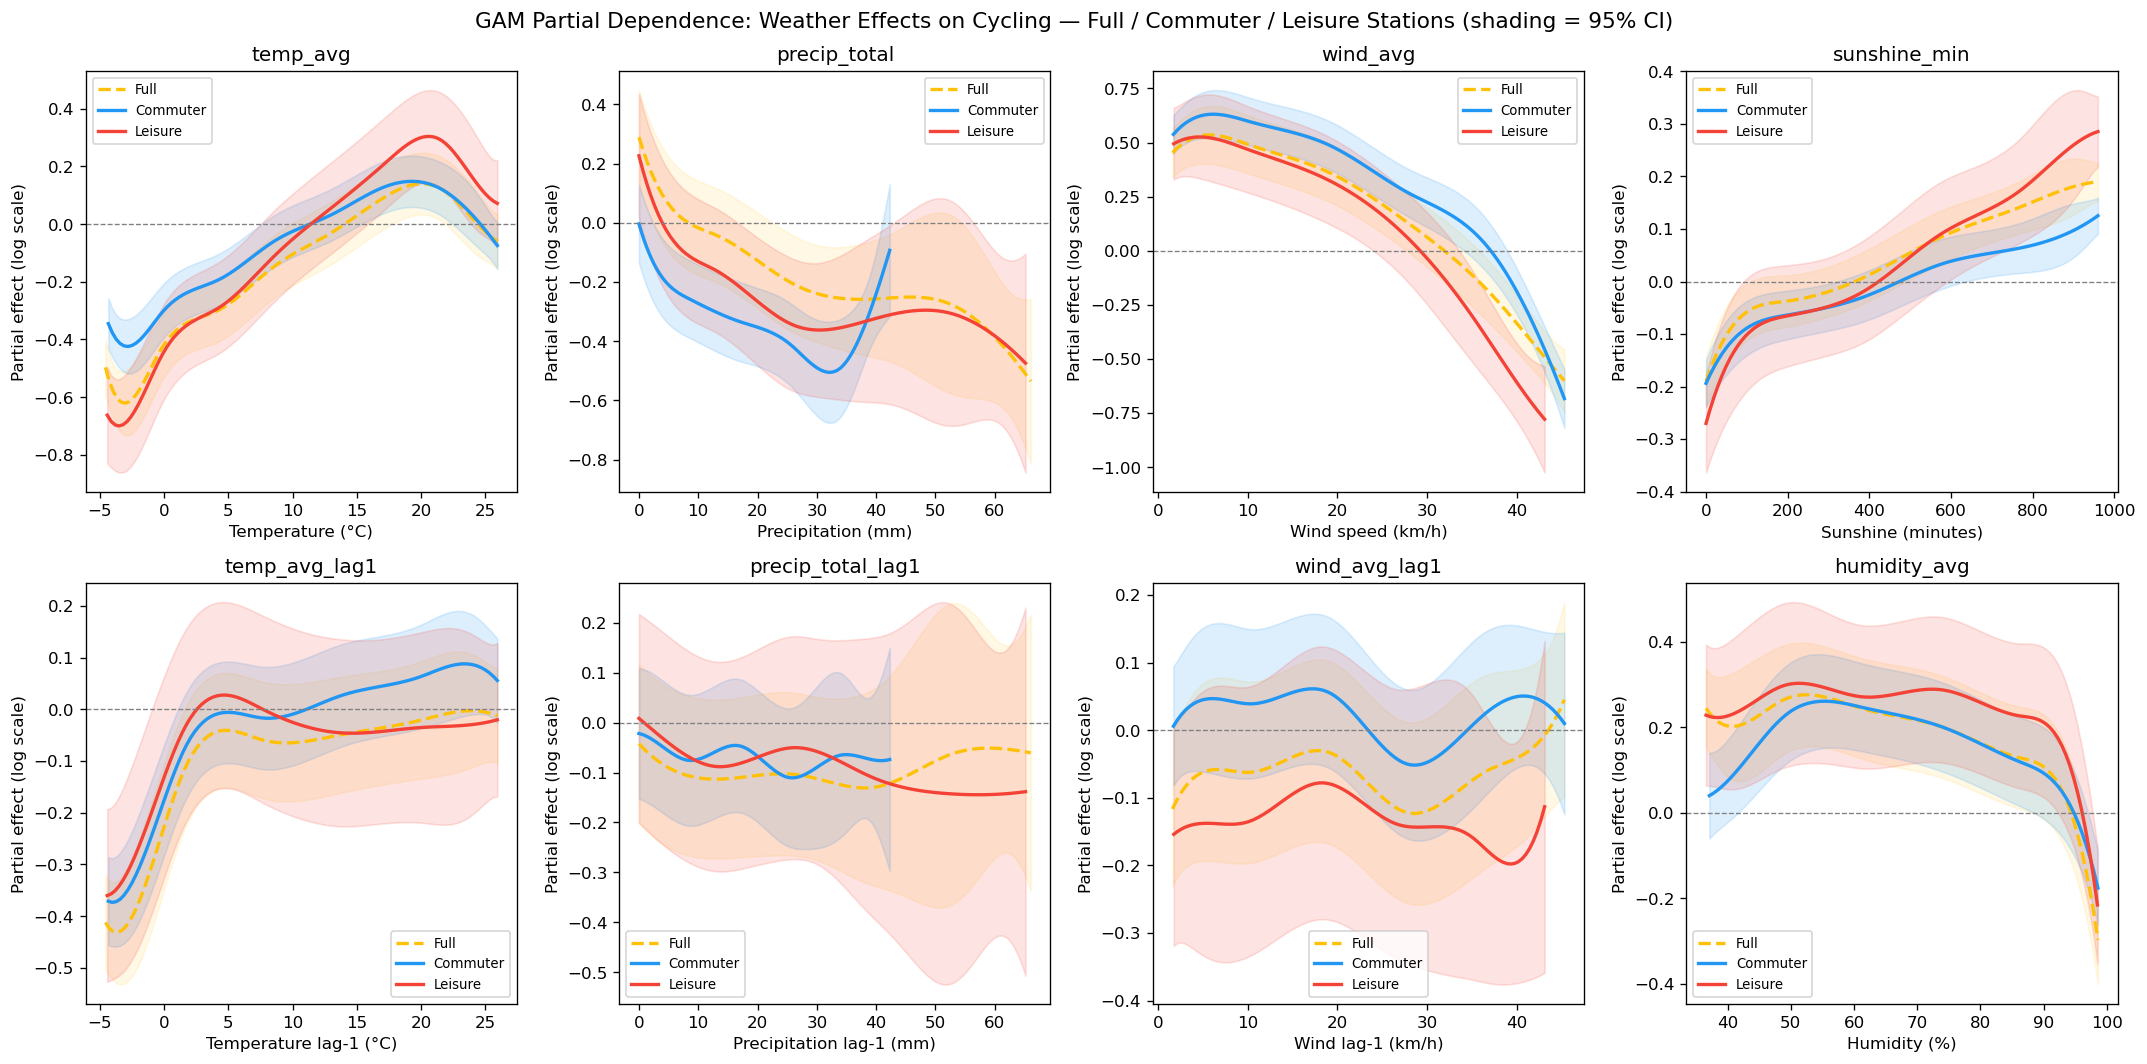

08_gam_partial_dependence saved.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

weather_terms = [
    (0, "temp_avg",           "Temperature (°C)",        axes[0, 0]),
    (1, "precip_total",       "Precipitation (mm)",       axes[0, 1]),
    (2, "wind_avg",           "Wind speed (km/h)",        axes[0, 2]),
    (3, "sunshine_min",       "Sunshine (minutes)",       axes[0, 3]),
    (5, "temp_avg_lag1",      "Temperature lag-1 (°C)",  axes[1, 0]),
    (6, "precip_total_lag1",  "Precipitation lag-1 (mm)", axes[1, 1]),
    (7, "wind_avg_lag1",      "Wind lag-1 (km/h)",        axes[1, 2]),
    (4, "humidity_avg",       "Humidity (%)",             axes[1, 3]),
]

def inv_x(XX, term_idx, scaler_obj):
    """Inverse-transform one column of a GAM grid back to original units."""
    dummy = np.zeros((len(XX), len(continuous_idx)))
    dummy[:, term_idx] = XX[:, term_idx]
    return scaler_obj.inverse_transform(dummy)[:, term_idx]

MONTH_IDX = ALL_FEATURES.index("month")  # index 9

for term_idx, feat_name, xlabel, ax in weather_terms:
    XX_f = gam_full.generate_X_grid(term=term_idx)
    XX_c = gam_commuter.generate_X_grid(term=term_idx)
    XX_l = gam_leisure.generate_X_grid(term=term_idx)

    # generate_X_grid fills non-varied features with 0; fix month (factor, domain 1–12)
    XX_f[:, MONTH_IDX] = 6
    XX_c[:, MONTH_IDX] = 6
    XX_l[:, MONTH_IDX] = 6

    pdep_f, confi_f = gam_full.partial_dependence(term=term_idx, X=XX_f, width=0.95)
    pdep_c, confi_c = gam_commuter.partial_dependence(term=term_idx, X=XX_c, width=0.95)
    pdep_l, confi_l = gam_leisure.partial_dependence(term=term_idx, X=XX_l, width=0.95)

    # Convert scaled grid values back to original units for x-axis display
    x_f = inv_x(XX_f, term_idx, scaler)
    x_c = inv_x(XX_c, term_idx, scaler_c)
    x_l = inv_x(XX_l, term_idx, scaler_l)

    ax.plot(x_f, pdep_f, color=COLORS["mixed"],    linewidth=2, linestyle="--", label="Full")
    ax.fill_between(x_f, confi_f[:, 0], confi_f[:, 1], alpha=0.10, color=COLORS["mixed"])
    ax.plot(x_c, pdep_c, color=COLORS["commuter"], linewidth=2, label="Commuter")
    ax.fill_between(x_c, confi_c[:, 0], confi_c[:, 1], alpha=0.15, color=COLORS["commuter"])
    ax.plot(x_l, pdep_l, color=COLORS["leisure"],  linewidth=2, label="Leisure")
    ax.fill_between(x_l, confi_l[:, 0], confi_l[:, 1], alpha=0.15, color=COLORS["leisure"])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Partial effect (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Partial Dependence: Weather Effects on Cycling — "
    "Full / Commuter / Leisure Stations (shading = 95% CI)",
    fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "08_gam_partial_dependence.png", dpi=150)
plt.show()
print("08_gam_partial_dependence saved.")

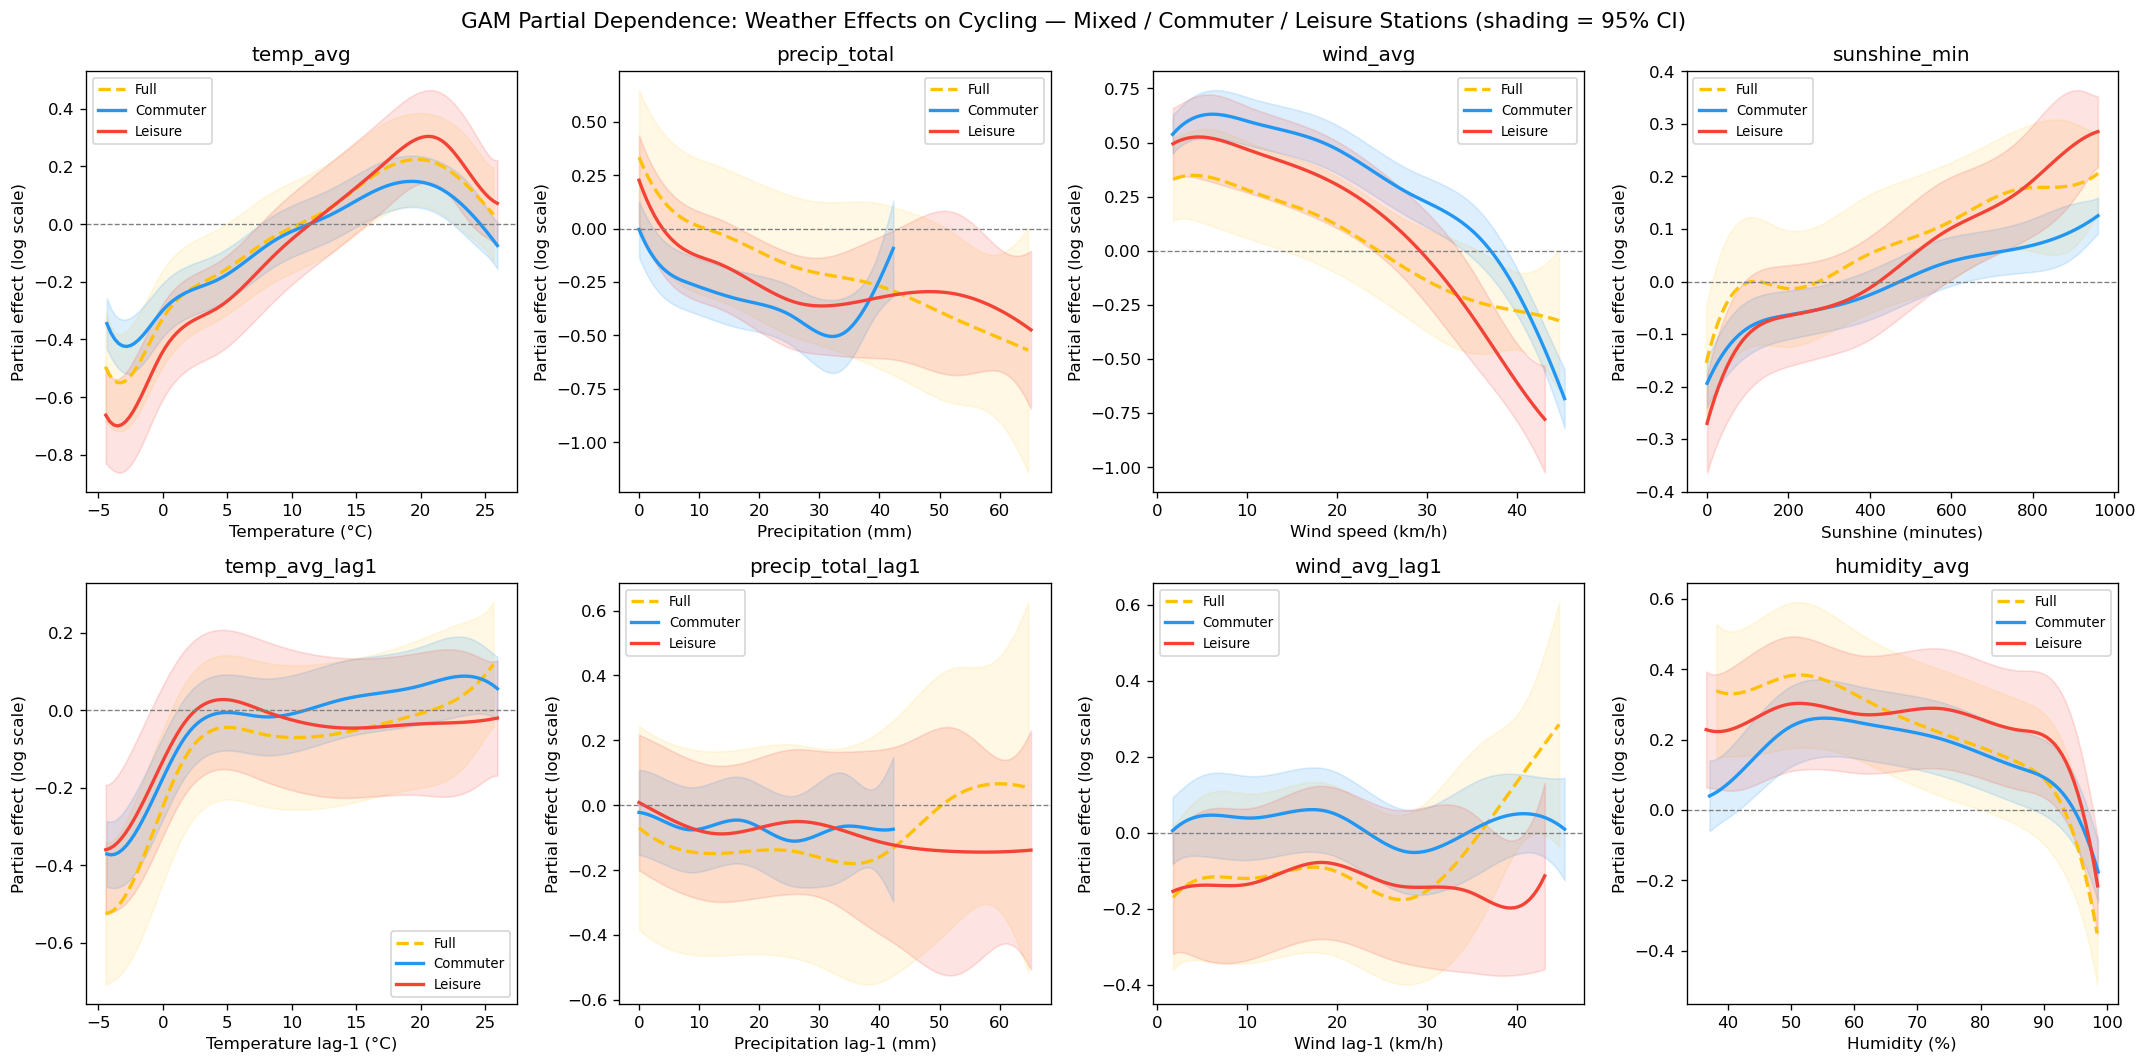

08_gam_partial_dependence.2 saved.


In [ ]:
#with mixed orientation site
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

weather_terms = [
    (0, "temp_avg",           "Temperature (°C)",        axes[0, 0]),
    (1, "precip_total",       "Precipitation (mm)",       axes[0, 1]),
    (2, "wind_avg",           "Wind speed (km/h)",        axes[0, 2]),
    (3, "sunshine_min",       "Sunshine (minutes)",       axes[0, 3]),
    (5, "temp_avg_lag1",      "Temperature lag-1 (°C)",  axes[1, 0]),
    (6, "precip_total_lag1",  "Precipitation lag-1 (mm)", axes[1, 1]),
    (7, "wind_avg_lag1",      "Wind lag-1 (km/h)",        axes[1, 2]),
    (4, "humidity_avg",       "Humidity (%)",             axes[1, 3]),
]

def inv_x(XX, term_idx, scaler_obj):
    """Inverse-transform one column of a GAM grid back to original units."""
    dummy = np.zeros((len(XX), len(continuous_idx)))
    dummy[:, term_idx] = XX[:, term_idx]
    return scaler_obj.inverse_transform(dummy)[:, term_idx]

MONTH_IDX = ALL_FEATURES.index("month")  # index 9

for term_idx, feat_name, xlabel, ax in weather_terms:
    XX_m = gam_mixed.generate_X_grid(term=term_idx)
    XX_c = gam_commuter.generate_X_grid(term=term_idx)
    XX_l = gam_leisure.generate_X_grid(term=term_idx)

    # generate_X_grid fills non-varied features with 0; fix month (factor, domain 1–12)
    XX_m[:, MONTH_IDX] = 6
    XX_c[:, MONTH_IDX] = 6
    XX_l[:, MONTH_IDX] = 6

    pdep_m, confi_m = gam_mixed.partial_dependence(term=term_idx, X=XX_m, width=0.95)
    pdep_c, confi_c = gam_commuter.partial_dependence(term=term_idx, X=XX_c, width=0.95)
    pdep_l, confi_l = gam_leisure.partial_dependence(term=term_idx, X=XX_l, width=0.95)

    # Convert scaled grid values back to original units for x-axis display
    x_m = inv_x(XX_m, term_idx, scaler)
    x_c = inv_x(XX_c, term_idx, scaler_c)
    x_l = inv_x(XX_l, term_idx, scaler_l)

    ax.plot(x_m, pdep_m, color=COLORS["mixed"],    linewidth=2, linestyle="--", label="Full")
    ax.fill_between(x_m, confi_m[:, 0], confi_m[:, 1], alpha=0.10, color=COLORS["mixed"])
    ax.plot(x_c, pdep_c, color=COLORS["commuter"], linewidth=2, label="Commuter")
    ax.fill_between(x_c, confi_c[:, 0], confi_c[:, 1], alpha=0.15, color=COLORS["commuter"])
    ax.plot(x_l, pdep_l, color=COLORS["leisure"],  linewidth=2, label="Leisure")
    ax.fill_between(x_l, confi_l[:, 0], confi_l[:, 1], alpha=0.15, color=COLORS["leisure"])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Partial effect (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Partial Dependence: Weather Effects on Cycling — "
    "Mixed / Commuter / Leisure Stations (shading = 95% CI)",
    fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "08_gam_partial_dependence.2.png", dpi=150)
plt.show()
print("08_gam_partial_dependence.2 saved.")

## 8. Weather-Normalized Cycling Index

Normalized cycling index saved.


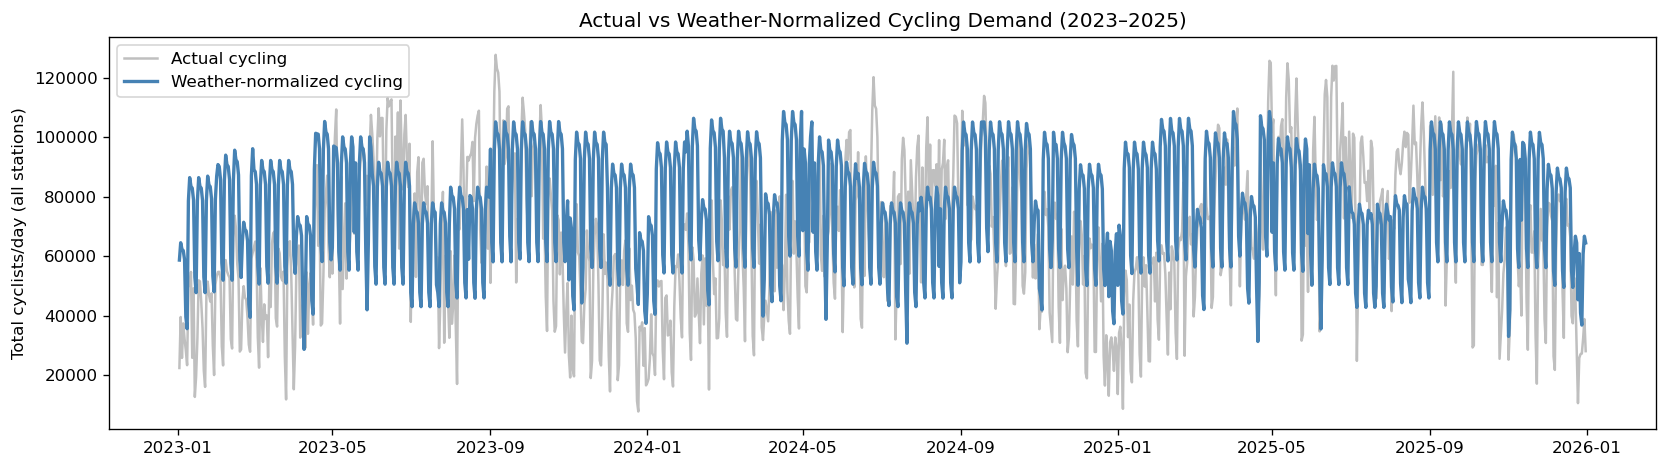

08_normalized_vs_actual saved.


In [ ]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed = ALL_FEATURES + ["site_offset"]
panel_norm_clean = panel_norm[cols_needed + ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]].dropna()

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(float)
for feat, val_ref in ref_weather.items():
    idx = ALL_FEATURES.index(feat)
    X_norm[:, idx] = val_ref

X_norm_s = X_norm.copy()
X_norm_s[:, continuous_idx] = scaler.transform(X_norm[:, continuous_idx])

y_adj_pred = gam_full.predict(X_norm_s)
offset     = panel_norm_clean["site_offset"].values
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(np.expm1(y_adj_pred + offset), 0, None)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2, label="Weather-normalized cycling")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023\u20132025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08_normalized_vs_actual.png", dpi=150)
plt.show()
print("08_normalized_vs_actual saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions (low temperatures, rain) rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period. This reflects the day-of-week effect (weekend peaks vs. weekday troughs). Since normalization only removes weather variation, calendar signals remain intact in the normalized counts — consistent with model expectations.

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level (~60,000–90,000 cyclists/day across all stations) from 2023 through 2025, with no sustained upward trend. Under the assumption of identical reference weather conditions, the underlying cycling demand at AWV stations appears structurally stable over this period.

**4. Favourable summers generate a weather bonus above the reference level**
   
During spring–summer 2023 and summer 2024, the actual curve periodically exceeds the normalized curve, indicating that real weather conditions on those days were better than the reference scenario (15 °C, 0 mm rain, 300 min sunshine, 10 km/h wind), producing additional weather-driven cycling above the modelled baseline.

**5. The late-2024 / early-2025 dip is weather-driven, not structural**
   
A pronounced trough is visible in the actual curve around December 2024 – January 2025, while the normalized curve remains relatively flat over the same period. This confirms the dip was caused by an episode of severe weather (cold spell or persistent rain) rather than a structural decline in cycling demand.

## 9. Weather Effect Magnitudes

In [ ]:
# Extract per-row site offsets aligned with each training X matrix
def get_offsets(df, features):
    cols = features + ["aantal", "site_offset"]
    return df[cols].dropna()["site_offset"].values

offsets_full = get_offsets(train,   ALL_FEATURES)
offsets_c    = get_offsets(train_c, ALL_FEATURES)
offsets_l    = get_offsets(train_l, ALL_FEATURES)
offsets_m    = get_offsets(train_m, ALL_FEATURES)
def weather_effect_ame(gam, X_scaled, offsets, feature_idx, bad_val, ref_val, scaler_obj):
    """
    Average Marginal Effect: for every training row, change one weather variable
    from ref_val to bad_val (all else fixed), then average the % change in predicted count.
    """
    X_bad = X_scaled.copy()
    X_ref = X_scaled.copy()
    if feature_idx in continuous_idx:
        pos = continuous_idx.index(feature_idx)
        X_bad[:, feature_idx] = (bad_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
        X_ref[:, feature_idx] = (ref_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
    else:
        X_bad[:, feature_idx] = bad_val
        X_ref[:, feature_idx] = ref_val
    y_bad = np.expm1(gam.predict(X_bad) + offsets)
    y_ref = np.expm1(gam.predict(X_ref) + offsets)
    pct_changes = (y_bad - y_ref) / np.where(y_ref > 0, y_ref, np.nan) * 100
    return np.nanmean(pct_changes)

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0°C vs 15°C)",      0,  0.0,  15.0),
    ("Cool day (8°C vs 15°C)",      0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("=" * 80)
print("GAM WEATHER EFFECT SIZES  (Average Marginal Effect, train 2023–2024)")
print("=" * 80)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8} | {'Mixed':>7}")
print("-" * 80)
for label, feat_idx, bad_val, ref_val in comparisons:
    eff_full = weather_effect_ame(gam_full,     X_train_s,  offsets_full, feat_idx, bad_val, ref_val, scaler)
    eff_c    = weather_effect_ame(gam_commuter, X_train_cs, offsets_c,    feat_idx, bad_val, ref_val, scaler_c)
    eff_l    = weather_effect_ame(gam_leisure,  X_train_ls, offsets_l,    feat_idx, bad_val, ref_val, scaler_l)
    eff_m    = weather_effect_ame(gam_mixed,    X_train_ms, offsets_m,    feat_idx, bad_val, ref_val, scaler_m)
    print(f"{label:<35} | {eff_full:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}% | {eff_m:>7.1f}%")
print()
print("Each estimate is the mean % change across all training observations")
print("when one weather variable changes, all other variables held fixed.")

GAM WEATHER EFFECT SIZES  (Average Marginal Effect, train 2023–2024)
Condition                           |    Full |  Commuter |  Leisure |   Mixed
--------------------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -34.4% |    -29.7% |   -39.2% |   -35.6%
Light rain (2mm vs 0mm)             |  -11.0% |    -10.7% |   -12.7% |   -11.1%
Cold day (0°C vs 15°C)              |  -36.3% |    -31.9% |   -43.8% |   -35.9%
Cool day (8°C vs 15°C)              |  -17.9% |    -14.7% |   -23.4% |   -16.7%
Strong wind (40 vs 10 km/h)         |  -56.8% |    -55.1% |   -66.6% |   -43.0%
No sunshine (0 vs 300 min)          |  -15.9% |    -13.6% |   -20.2% |   -15.2%

Each estimate is the mean % change across all training observations
when one weather variable changes, all other variables held fixed.


## 10. Save Models

In [ ]:
#serialize the fitted GAM models and related objects for future use 
models = {
    "gam_full"     : gam_full,
    "gam_commuter" : gam_commuter,
    "gam_leisure"  : gam_leisure,
    "gam_mixed"    : gam_mixed,
    "scaler"       : scaler,
    "scaler_c"     : scaler_c,
    "scaler_l"     : scaler_l,
    "scaler_m"     : scaler_m,
    "site_log_mean": site_log_mean,
    "continuous_idx": continuous_idx,
    "ALL_FEATURES" : ALL_FEATURES,
}
with open(PROCESSED / "gam_models.pkl", "wb") as fh: 
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models.pkl'}")


Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/gam_models.pkl


## 10. Final Summary

In [ ]:
heavy_rain_full = weather_effect_ame(gam_full, X_train_s, offsets_full, 1, 20.0,  0.0, scaler)
cold_day_full   = weather_effect_ame(gam_full, X_train_s, offsets_full, 0,  0.0, 15.0, scaler)
strong_wind_full= weather_effect_ame(gam_full, X_train_s, offsets_full, 2, 40.0, 10.0, scaler)

print("=" * 52)
print("GAM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2023–2024 ({len(y_train_adj):,} observations)")
print(f"Test period     : 2025     ({len(y_test_adj):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full GAM     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter GAM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure GAM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print(f"  Mixed GAM    : MAE={mae_m:.1f}, R²={r2_m:.3f}")
print()
print("Key weather effects on cycling demand (full model, AME):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")

GAM MODELLING SUMMARY
Training period : 2023–2024 (96,038 observations)
Test period     : 2025     (48,151 observations)

Model performance (test set):
  Full GAM     : MAE=148.5, R²=0.784
  Commuter GAM : MAE=125.4, R²=0.896
  Leisure GAM  : MAE=184.4, R²=0.555
  Mixed GAM    : MAE=131.5, R²=0.788

Key weather effects on cycling demand (full model, AME):
  Heavy rain (20mm) : -34.4%
  Cold day (0°C)    : -36.3%
  Strong wind       : -56.8%
